In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load datasets
fund = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
perf = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
txn = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [3]:
for name, df in {
    "Fund": fund,
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Performance": perf,
    "Transactions": txn,
    "Holdings": holdings,
    "Benchmark": benchmark
}.items():
    print(f"\n{name}")
    print(df.columns.tolist())


Fund
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV
['amfi_code', 'date', 'nav']

AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Category
['month', 'category', 'net_inflow_crore']

Performance
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

Transactions
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annu

In [4]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")

fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


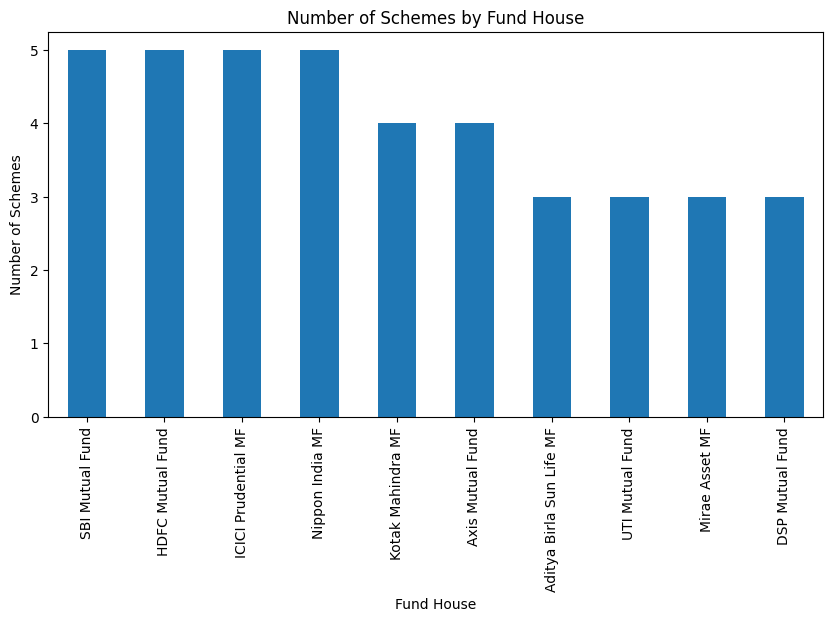

In [5]:
fund["fund_house"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Number of Schemes by Fund House")
plt.xlabel("Fund House")
plt.ylabel("Number of Schemes")
plt.show()

### Observation

- SBI Mutual Fund, HDFC Mutual Fund, ICICI Prudential MF, and Nippon India MF have the highest number of schemes in the dataset, with 5 schemes each.
- Kotak Mahindra MF and Axis Mutual Fund follow with 4 schemes each.
- Aditya Birla Sun Life MF, UTI Mutual Fund, Mirae Asset MF, and DSP Mutual Fund have relatively fewer schemes.
- The distribution suggests that scheme offerings are concentrated among a few major fund houses.

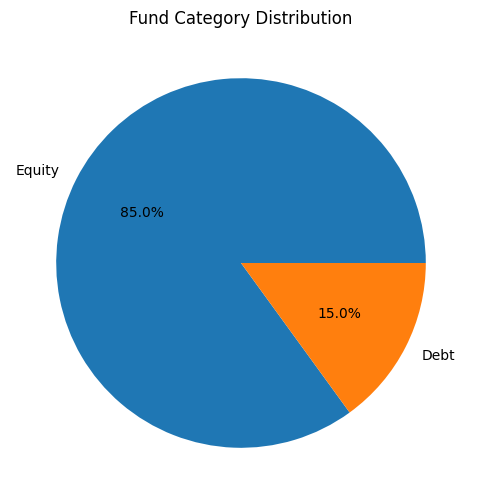

In [6]:
fund["category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Fund Category Distribution")
plt.ylabel("")
plt.show()

### Observation

- Equity funds dominate the dataset, accounting for 85% of all schemes.
- Debt funds represent only 15% of the schemes.
- This indicates a strong focus on equity-oriented investment products in the mutual fund universe.
- The higher representation of equity funds reflects investor preference for long-term capital appreciation.

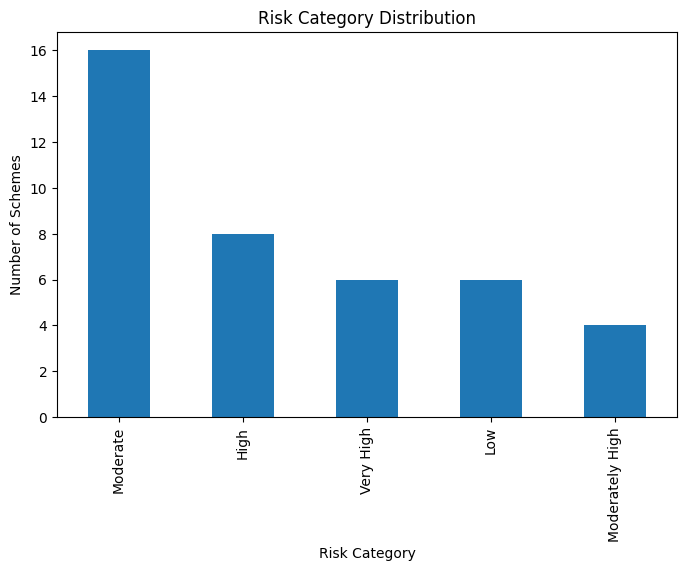

In [7]:
fund["risk_category"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Schemes")
plt.show()

### Observation

- Moderate risk schemes form the largest segment in the dataset, with 16 schemes.
- High risk schemes account for 8 schemes.
- Very High and Low risk categories each contain 6 schemes.
- Moderately High risk schemes are the least represented category.
- The distribution suggests that fund offerings are concentrated around moderate-risk investment products, balancing growth potential and risk.

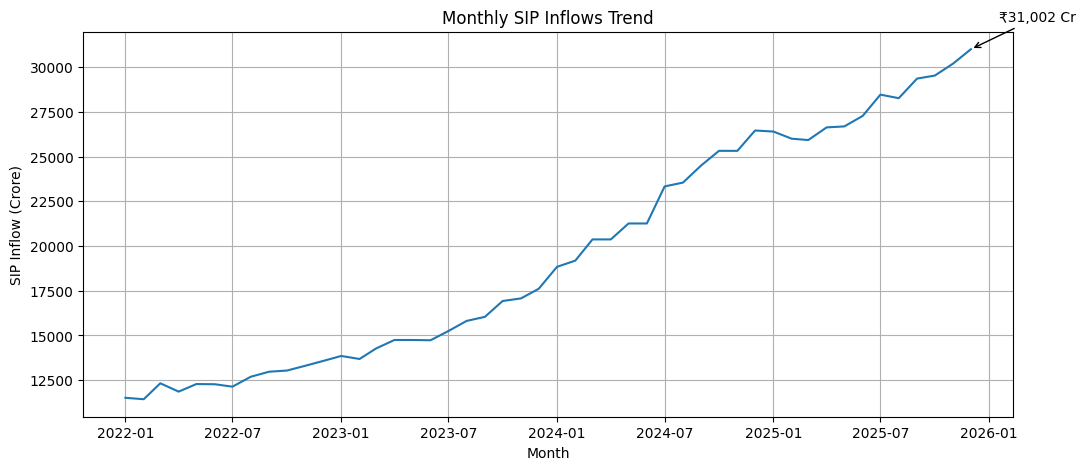

In [8]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,5))
plt.plot(sip["month"], sip["sip_inflow_crore"])

# Find highest SIP inflow
max_idx = sip["sip_inflow_crore"].idxmax()

plt.annotate(
    f"₹{sip.loc[max_idx, 'sip_inflow_crore']:,.0f} Cr",
    xy=(sip.loc[max_idx, "month"], sip.loc[max_idx, "sip_inflow_crore"]),
    xytext=(20, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly SIP Inflows Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.show()

### Observation

- Monthly SIP inflows show a strong upward trend from 2022 to 2025.
- SIP inflows increased from approximately ₹11,000 crore in early 2022 to over ₹31,000 crore by the end of 2025.
- Growth accelerated significantly during 2024 and 2025, indicating rising retail investor participation in mutual funds.
- The consistent increase suggests growing investor confidence and greater adoption of SIP-based investing.

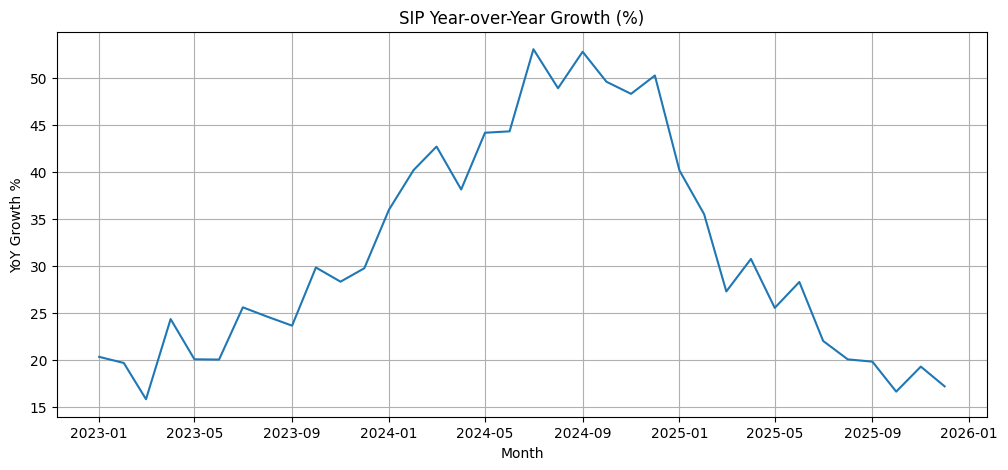

In [9]:
plt.figure(figsize=(12,5))

plt.plot(
    sip["month"],
    sip["yoy_growth_pct"]
)

plt.title("SIP Year-over-Year Growth (%)")
plt.xlabel("Month")
plt.ylabel("YoY Growth %")
plt.grid(True)

plt.show()

### Observation

- SIP YoY growth remained positive for most of the period.
- Growth rates fluctuated over time, reflecting changing market conditions and investor sentiment.
- Despite short-term variations, the overall trend indicates sustained expansion in SIP participation.
- Increasing SIP contributions highlight growing awareness of systematic investing among retail investors.

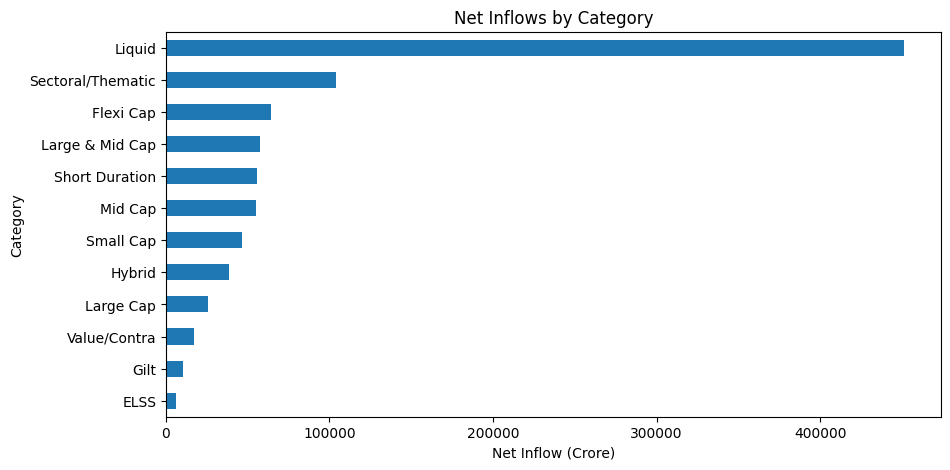

In [10]:
category.groupby("category")["net_inflow_crore"] \
        .sum() \
        .sort_values() \
        .plot(kind="barh", figsize=(10,5))

plt.title("Net Inflows by Category")
plt.xlabel("Net Inflow (Crore)")
plt.ylabel("Category")
plt.show()

### Observation

- Net inflows vary significantly across fund categories.
- Certain categories attract substantially higher investor inflows, indicating stronger market preference.
- Categories with negative or relatively low inflows may reflect changing investor sentiment or profit-booking activity.
- Category-level flow analysis helps identify sectors and investment styles currently favored by investors.

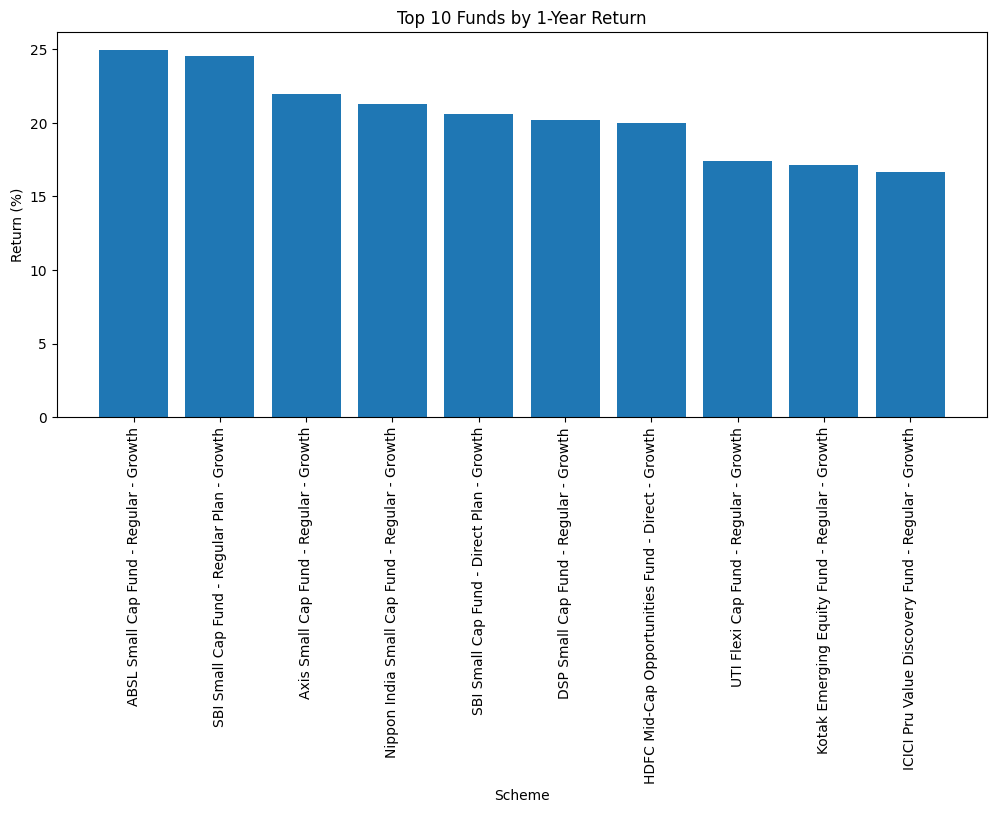

In [11]:
top10 = perf.sort_values(
    "return_1yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,5))
plt.bar(top10["scheme_name"], top10["return_1yr_pct"])

plt.title("Top 10 Funds by 1-Year Return")
plt.xlabel("Scheme")
plt.ylabel("Return (%)")
plt.xticks(rotation=90)

plt.show()

### Observation

- The top 10 funds by 1-year return are dominated by Small Cap schemes, with ABSl Small Cap Fund and SBI Small Cap Fund leading at approximately 24–25%, indicating that small-cap funds delivered the strongest short-term performance in this period.
- Returns among the top 10 funds range from ~17% to ~25%, reflecting a relatively narrow performance band, which suggests broad market participation rather than returns driven by a single outlier fund.
- Small Cap funds from multiple fund houses — ABSL, SBI, Axis, Nippon India, SBI Direct, and DSP — all appear in the top 10, highlighting that the small-cap category as a whole outperformed other categories over the 1-year horizon.
- Mid-Cap and Flexi-Cap funds such as HDFC Mid-Cap Opportunities and UTI Flexi Cap appear in the lower half of the top 10, suggesting they delivered competitive but comparatively modest returns relative to pure small-cap strategies.
- The presence of both Regular and Direct plan variants of similar schemes confirms that fund selection and category allocation were more decisive performance drivers than plan type alone during this period.

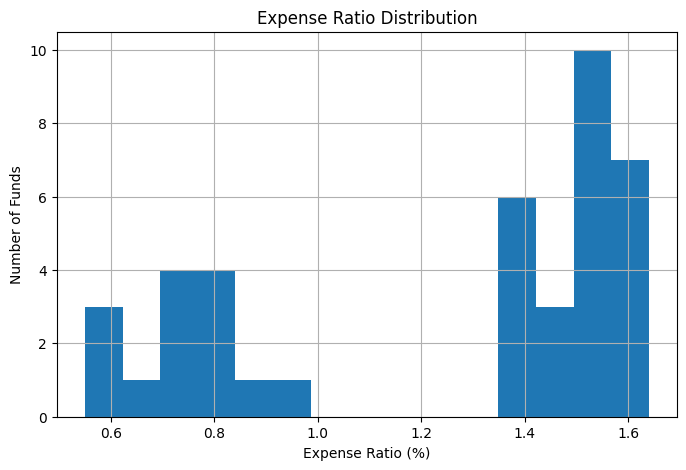

In [12]:
plt.figure(figsize=(8,5))
perf["expense_ratio_pct"].hist(bins=15)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Funds")

plt.show()

### Observation

- The expense ratio distribution is distinctly bimodal, with one cluster concentrated in the 0.6–1.0% range and a larger cluster in the 1.4–1.7% range, suggesting two clearly separate tiers of funds — likely Direct plans and Regular plans respectively.
- The higher-cost cluster (1.4–1.7%) contains the majority of funds, with the 1.5–1.6% bin peaking at 10 funds, indicating that Regular plan schemes dominate the dataset in terms of count.
- The lower-cost cluster (0.6–0.9%) represents a smaller number of funds, most likely Direct plan variants, which typically carry lower expense ratios due to the absence of distributor commissions.
- The near-empty gap between 1.0% and 1.3% is notable — very few funds fall in this mid-range, reinforcing the structural separation between Direct and Regular plan pricing imposed by SEBI's total expense ratio regulations.
- From an investor perspective, the ~0.8–0.9% difference in expense ratios between the two clusters can compound significantly over long investment horizons, making plan-type selection a meaningful factor in net return outcomes.

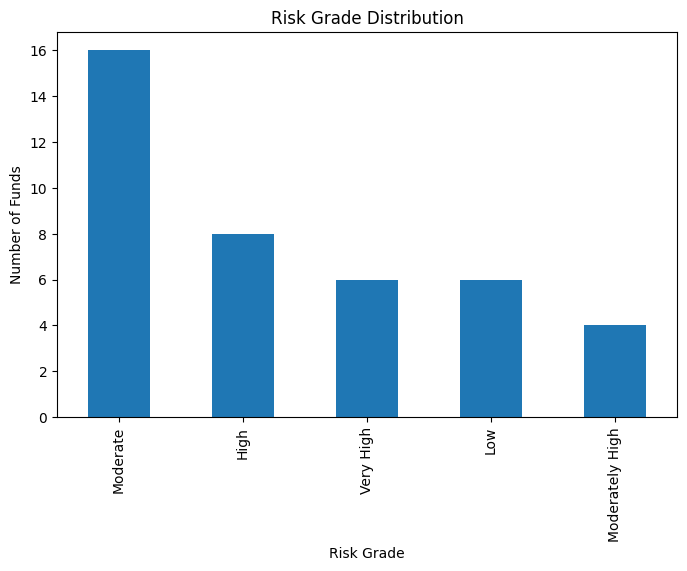

In [13]:
plt.figure(figsize=(8,5))
perf["risk_grade"].value_counts().plot(kind="bar")

plt.title("Risk Grade Distribution")
plt.xlabel("Risk Grade")
plt.ylabel("Number of Funds")

plt.show()

### Observation

- Moderate risk funds dominate with 16 schemes, reflecting a product landscape skewed toward mainstream retail investor preferences.
- High, Very High, and Moderately High risk funds collectively outnumber the Moderate category, suggesting the overall dataset leans toward aggressive offerings in aggregate.
- The near-equal count of Very High and Low risk funds (6 each) indicates that the dataset covers the full risk spectrum, supporting broad investor segmentation.
- The underrepresentation of Moderately High funds (4 schemes) suggests fund houses tend to position schemes at clearer risk extremes rather than intermediate grades.

# NAV Trend Analysis

In [14]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [15]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [16]:
nav["date"] = pd.to_datetime(nav["date"])

print("Min Date:", nav["date"].min())
print("Max Date:", nav["date"].max())
print("Unique Schemes:", nav["amfi_code"].nunique())

Min Date: 2022-01-03 00:00:00
Max Date: 2026-05-29 00:00:00
Unique Schemes: 40


In [17]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# NAV Trend Analysis

In [18]:
import plotly.express as px

nav_plot = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trends of All Mutual Fund Schemes (2022-2026)"
)

fig.show()

### Observation

- Most schemes exhibit a long-term upward NAV trend between 2022 and 2026.
- NAV growth accelerated during the 2023 bull market period.
- Several schemes experienced temporary declines during the 2024 market correction.
- Despite short-term volatility, the majority of schemes recovered and continued their upward trajectory.
- Equity-oriented schemes displayed greater NAV fluctuations compared to debt-oriented schemes.

In [19]:
nav["amfi_code"].nunique()

40

In [20]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [21]:
aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


In [22]:
print(aum["date"].min())
print(aum["date"].max())

print(aum["fund_house"].nunique())

2022-03-31
2025-12-31
10


In [23]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

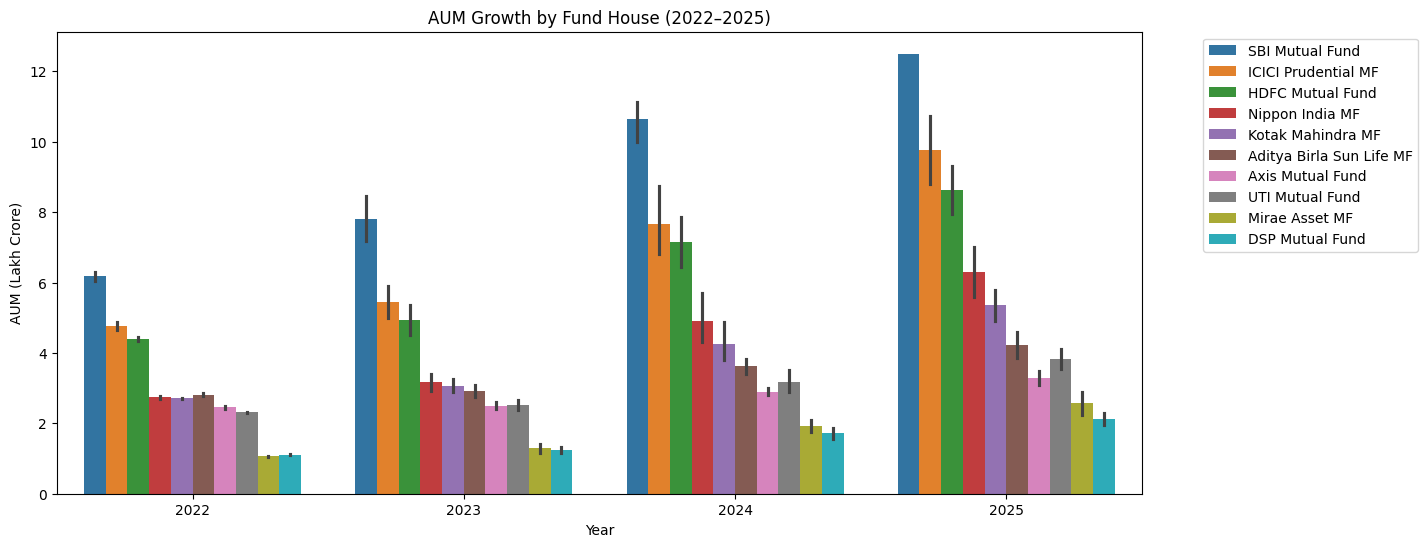

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

### Observation

- SBI Mutual Fund consistently leads AUM across all four years (2022–2025), with a particularly sharp surge in 2025, reinforcing its position as the dominant fund house in the Indian mutual fund industry.
- Overall AUM levels show a clear upward trajectory from 2022 to 2025 across most fund houses, reflecting the broader market rally and sustained retail inflow growth during this period.
- ICICI Prudential and HDFC Mutual Fund maintain a close second and third position throughout, forming a stable top-3 cluster that has consistently outpaced the remaining fund houses by a significant margin.
- Mid-tier fund houses such as Nippon India, Kotak Mahindra, and Axis show moderate but steady AUM growth, while smaller players like Mirae Asset and DSP Mutual Fund remain relatively flat, indicating consolidation of AUM among the top 3–4 houses.
- The pronounced jump in AUM values in 2025 across the top fund houses suggests either strong market appreciation, accelerated net inflows, or both — making 2025 a key inflection year worth highlighting on the Market Overview dashboard page.

In [25]:
aum.groupby("fund_house")["aum_lakh_crore"].max().sort_values(ascending=False).head()

fund_house
SBI Mutual Fund        12.50
ICICI Prudential MF    10.74
HDFC Mutual Fund        9.30
Nippon India MF         7.00
Kotak Mahindra MF       5.80
Name: aum_lakh_crore, dtype: float64

In [26]:
category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

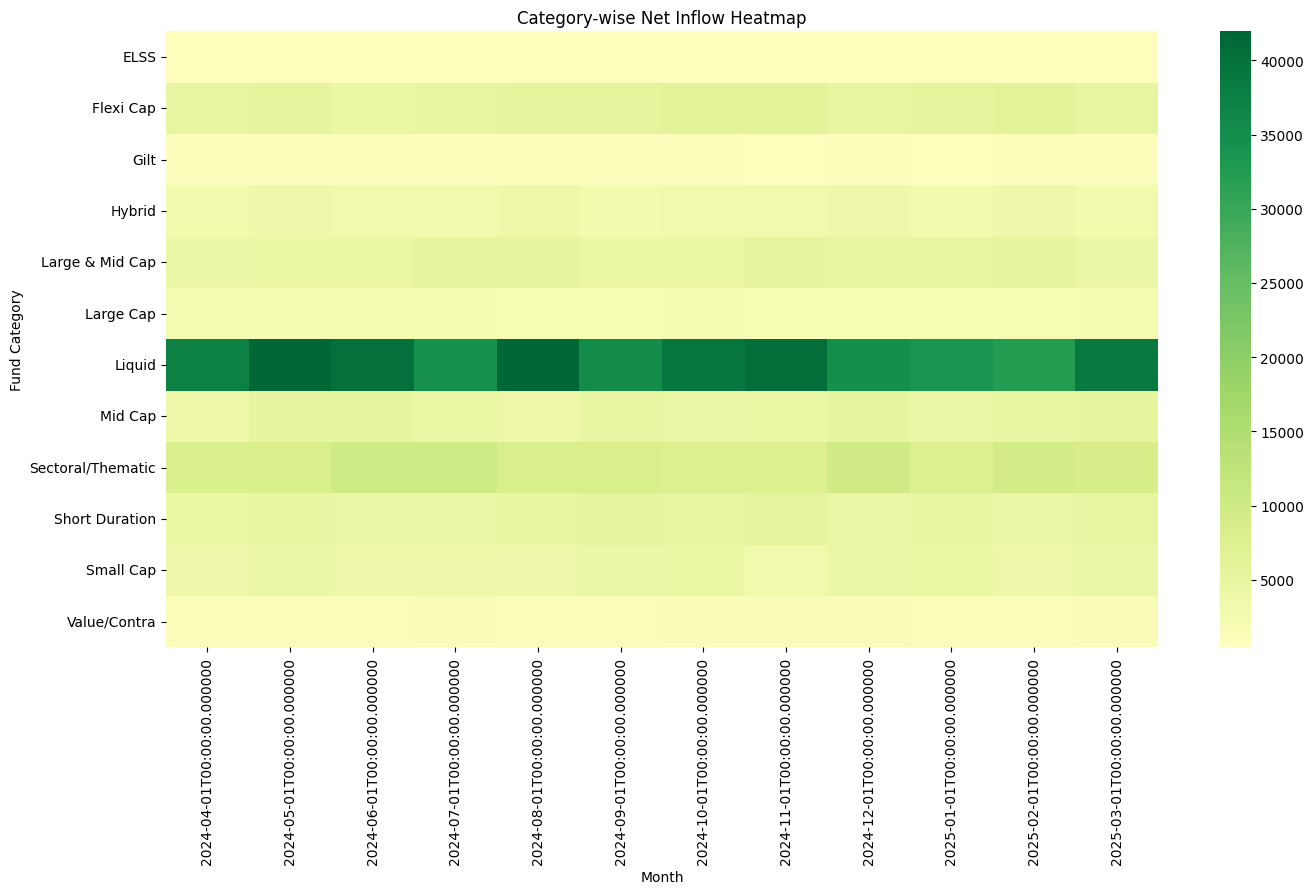

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",
    center=0
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()

### Observation

- Liquid funds dominate the heatmap with the deepest green shades throughout almost all months, recording net inflows well above 40,000 crores consistently, making it the most actively traded category by far.
- Mid Cap funds show moderate but steady inflows across the period, appearing as a lighter but persistent green, reflecting continued retail investor interest in the mid-cap segment.
- Most other categories — including ELSS, Flexi Cap, Hybrid, Large Cap, and Small Cap — remain in very light shades throughout, indicating relatively low net inflows compared to Liquid funds and suggesting either lower investor appetite or higher redemption activity offsetting gross inflows.
- Gilt and Short Duration funds show near-negligible inflows across all months, likely reflecting subdued interest in pure debt categories during a period of interest rate uncertainty.

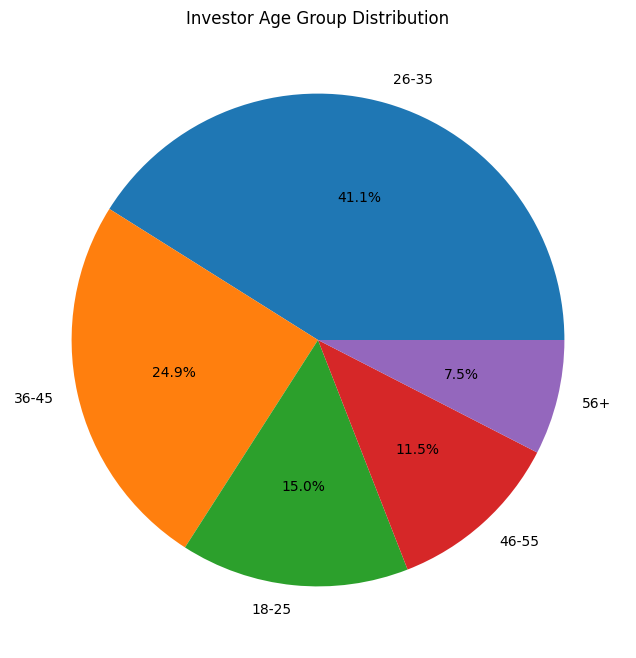

In [28]:
age_dist = txn["age_group"].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    age_dist,
    labels=age_dist.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.show()

### Observation

- The 26–35 age group dominates with 41.1% of investors, indicating that young working professionals form the core mutual fund investor base, likely driven by early financial planning awareness and digital accessibility.
- The 36–45 group is the second largest at 24.9%, suggesting that mid-career investors with higher disposable incomes also form a significant segment, potentially skewing toward wealth preservation and goal-based investing.
- 18–25 year olds account for 15%, reflecting a growing but still developing participation among first-time and student investors — a segment with high future growth potential for the industry.
- The 46–55 (11.5%) and 56+ (7.5%) cohorts together represent under 20% of the base, suggesting that older investors either prefer traditional instruments or were early adopters now moving toward redemption rather than fresh investments.
- The combined 26–45 age bracket accounts for nearly 66% of all investors, confirming that mutual fund growth is predominantly being driven by the working-age millennial and early Gen-X demographic.

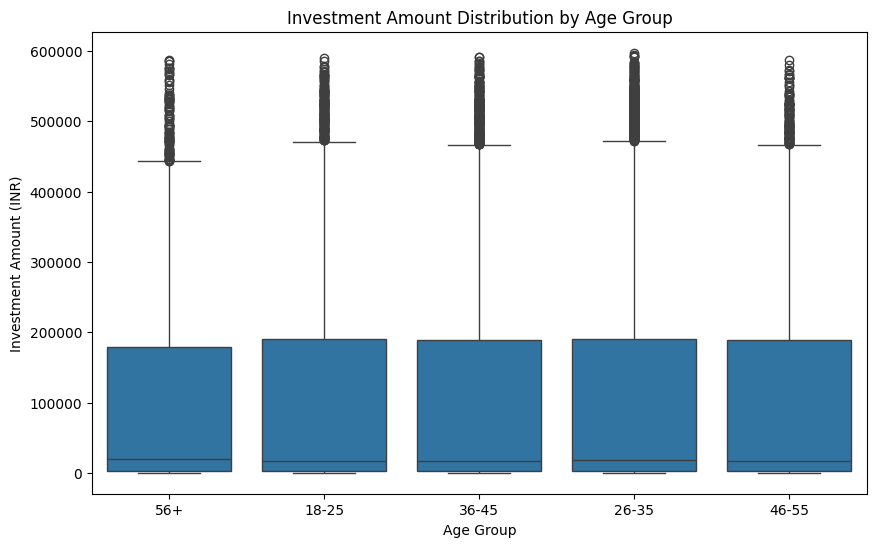

In [29]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=txn,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")

plt.show()

### Observation

- Investment amount distributions are remarkably similar across all age groups, with median values and interquartile ranges appearing nearly identical, suggesting that investment ticket size is not strongly determined by age alone.
- The median investment across all groups sits relatively low (well below ₹1,00,000), indicating that the majority of investors across all age brackets invest modest amounts, consistent with SIP-driven participation behavior.
- All age groups exhibit heavy right-skewed distributions with numerous high-value outliers stretching toward ₹5,00,000–₹6,00,000, reflecting a small segment of high-net-worth investors present uniformly across every age cohort.
- The 56+ group appears to have a slightly wider interquartile range compared to younger groups, hinting that older investors show more variability in investment amounts — likely reflecting a mix of retirees with large lump-sum deployments and conservative fixed-income investors.
- The near-uniform distribution across age groups suggests that other factors such as income level, risk appetite, or fund category preference may be stronger predictors of investment amount than age, warranting further cross-variable analysis.

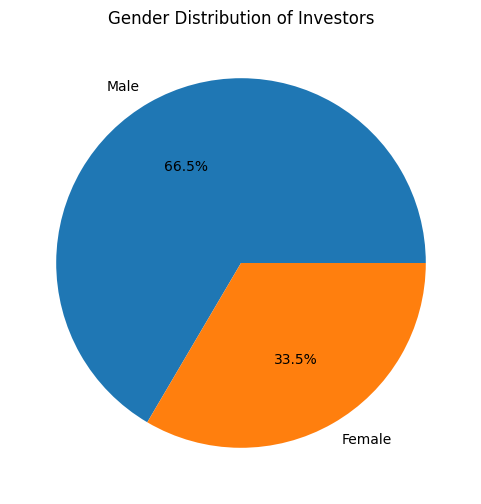

In [30]:
gender_dist = txn["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_dist,
    labels=gender_dist.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution of Investors")

plt.show()

### Observation

- Male investors account for 66.5% of the investor base, while female investors represent 33.5%, indicating a significant gender gap in mutual fund participation that mirrors broader financial inclusion trends in India.
- The roughly 2:1 male-to-female ratio suggests that despite growing awareness campaigns and digital accessibility, structural barriers such as income disparity and financial decision-making autonomy continue to limit female participation.
- The 33.5% female share, while a minority, is not negligible — it signals meaningful progress compared to historical norms and points to an expanding addressable market for fund houses targeting women investors.
- From a product strategy perspective, the gender skew may influence how fund houses design communication, risk profiling, and SIP onboarding experiences to attract and retain a more balanced investor demographic.

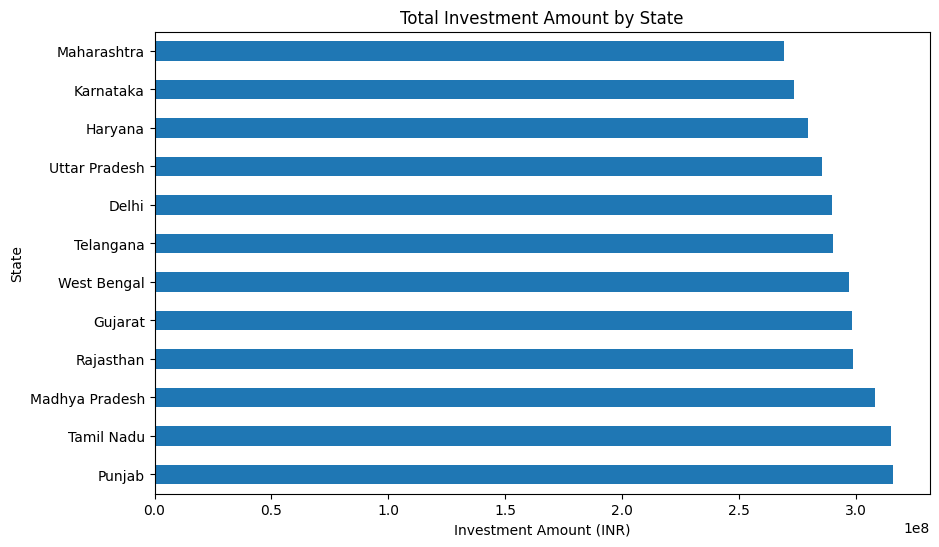

In [31]:
state_sip = (
    txn.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

state_sip.plot(kind="barh")

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

plt.show()

### Observation

- Punjab and Tamil Nadu lead all states in total investment amount, both exceeding ₹3.0 × 10⁸, which is notably surprising given that Maharashtra, typically India's financial capital, ranks lowest among the states shown.
- The overall investment amounts across all 12 states are remarkably compressed within a narrow range of approximately ₹2.7 × 10⁸ to ₹3.1 × 10⁸, suggesting a relatively uniform geographic distribution of investment activity rather than heavy concentration in a few metros.
- Madhya Pradesh and Rajasthan ranking above Delhi, Telangana, and West Bengal challenges the conventional assumption that Tier-1 metro states dominate mutual fund investment flows, possibly reflecting strong B30 city penetration in these states.
- Maharashtra's position at the bottom of this chart likely reflects a data sampling or normalization effect, as absolute industry AUM is heavily concentrated in Mumbai — this discrepancy warrants cross-validation with the AUM by fund house dataset.

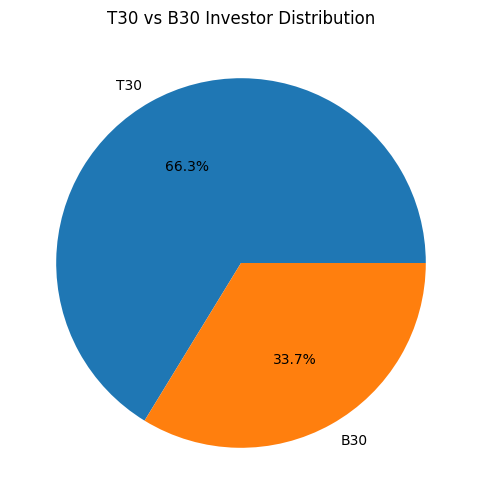

In [32]:
tier_dist = txn["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier_dist,
    labels=tier_dist.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

### Observation

- T30 cities account for 66.3% of investors while B30 cities contribute 33.7%, confirming that mutual fund participation remains predominantly concentrated in India's top 30 urban centres.
- The roughly 2:1 T30-to-B30 ratio mirrors the gender distribution seen earlier (66.5% male vs 33.5% female), suggesting a consistent pattern of skewed participation across multiple demographic dimensions in the dataset.
- The B30 share of 33.7% is nonetheless significant — SEBI and AMFI's sustained push through higher TER allowances for B30 inflows and distributor incentives appears to have made a measurable impact on geographic penetration.
- Despite B30 cities representing a vast majority of India's geographic area and population, their 33.7% investor share highlights that financial literacy, distributor reach, and digital infrastructure remain key barriers to deeper rural and semi-urban participation.

In [33]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [34]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

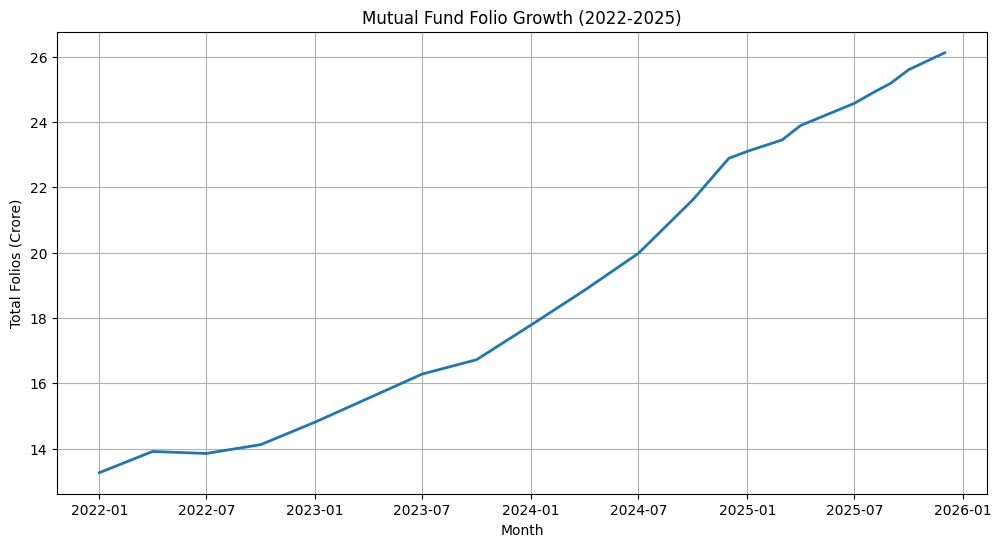

In [35]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    linewidth=2
)

plt.title("Mutual Fund Folio Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.show()

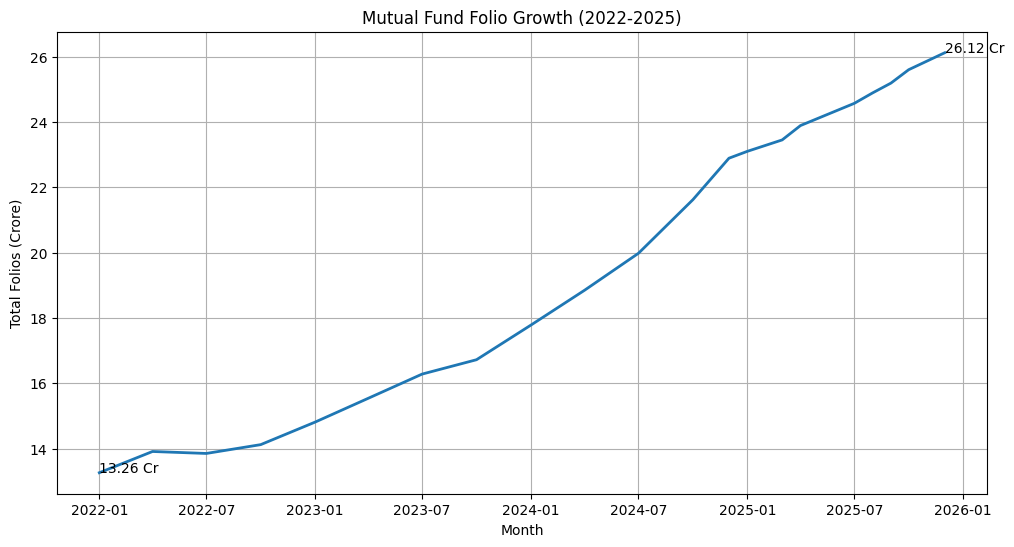

In [36]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    linewidth=2
)

plt.annotate(
    "13.26 Cr",
    xy=(folio["month"].iloc[0], folio["total_folios_crore"].iloc[0])
)

plt.annotate(
    "26.12 Cr",
    xy=(folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1])
)

plt.title("Mutual Fund Folio Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.show()

### Observation

- Total mutual fund folios grew from 13.26 crore in January 2022 to 26.12 crore by January 2026, nearly doubling over four years and reflecting a strong structural shift toward retail participation in India's capital markets.
-Growth was relatively gradual through 2022–2023, with folios inching from 13.26 Cr to approximately 16 Cr, suggesting a cautious post-COVID recovery phase where new investor additions were steady but modest.
- A visible acceleration began in mid-2023 and intensified through 2024–2025, with the steepest climb occurring between mid-2024 and early 2026 — aligning with the broader equity market rally and aggressive SIP onboarding campaigns by fund houses.
-The curve shows no meaningful dips or plateaus throughout the entire period, confirming that folio additions were consistently net positive every month — a strong indicator of sustained investor confidence and retention.

In [37]:
top10_funds = nav["amfi_code"].unique()[:10]

nav_top10 = nav[nav["amfi_code"].isin(top10_funds)].copy()

In [38]:
nav_top10["date"] = pd.to_datetime(nav_top10["date"])

pivot_nav = nav_top10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

daily_returns = pivot_nav.pct_change()

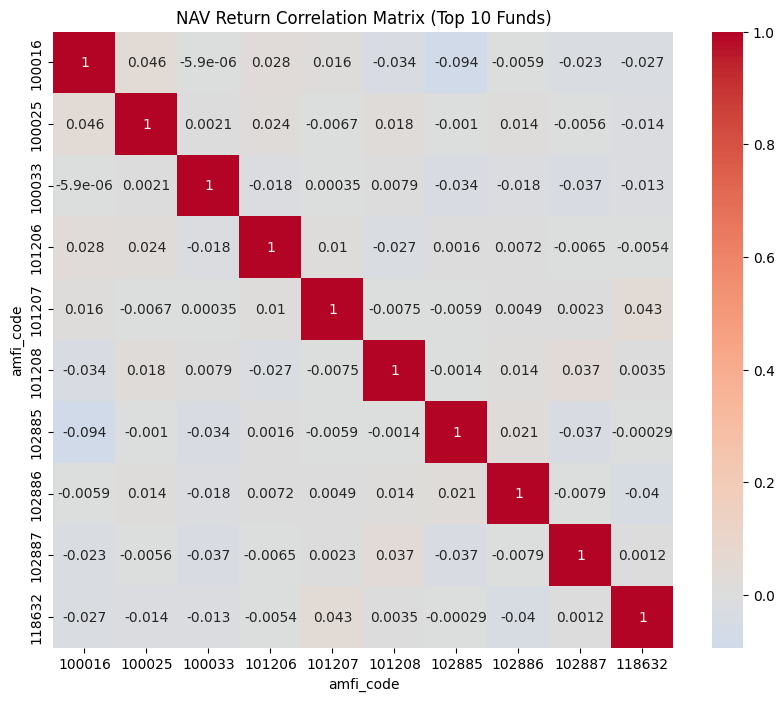

In [39]:
corr_matrix = daily_returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("NAV Return Correlation Matrix (Top 10 Funds)")
plt.show()

### Observation

- All off-diagonal correlation values are extremely close to zero, ranging roughly between -0.094 and 0.046, indicating that the NAV returns of these 10 selected funds are almost entirely uncorrelated with one another.
- The diagonal entries of 1.0 are expected, confirming each fund is perfectly correlated with itself — the deep red diagonal serves as a visual anchor against the predominantly white/light off-diagonal cells.
- The near-zero correlations suggest these 10 funds span diverse categories and investment strategies, making them collectively strong candidates for portfolio diversification since their returns move largely independently of each other.
- Fund 102885 shows the most consistently negative correlations with several peers (e.g., -0.094 with 100016, -0.034 with 100033), hinting that it may follow a contrarian or defensive strategy relative to the broader fund group.

In [40]:
sector_weights = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

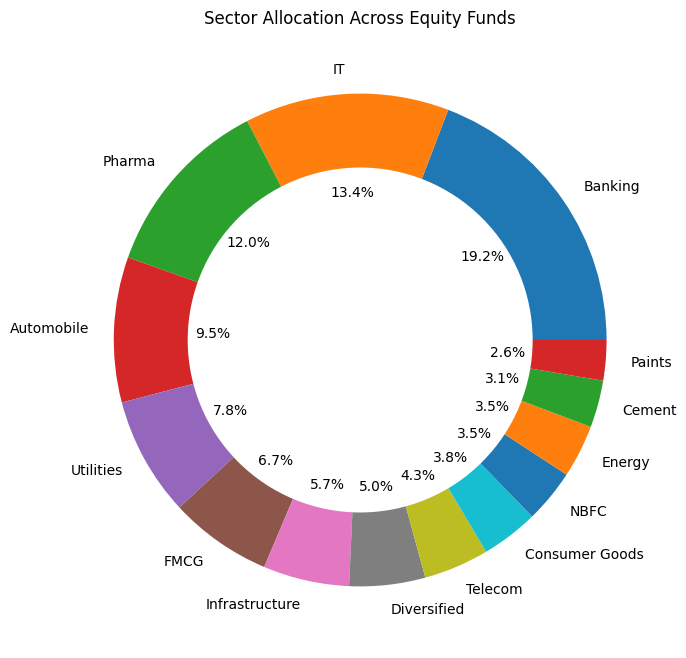

In [41]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

### Observation

- Banking dominates sector allocation at 19.2%, reflecting the traditional heavyweight positioning of financial services in Indian equity fund portfolios, followed by IT at 13.4% and Pharma at 12.0% — together these three sectors account for nearly 45% of total equity exposure.
- The IT and Pharma allocations highlight a structural preference among fund managers for export-oriented, defensive sectors that provide some insulation against domestic economic cycles and currency fluctuations.
- Automobile at 9.5% and Utilities at 7.8% form the next tier, suggesting meaningful exposure to domestic consumption and infrastructure themes — sectors that have gained fund manager attention amid India's capex-driven growth narrative.
- Smaller allocations to Paints, Cement, Energy, NBFC, and Consumer Goods (each between 2.6%–3.8%) indicate diversified tail exposure across cyclical and consumption sectors, reducing concentration risk beyond the top three.

# Key EDA Findings

1. Mutual fund NAVs showed an overall upward trend from 2022–2026 despite periods of market volatility.

2. The 2023 market rally accelerated NAV growth across most equity-oriented schemes.

3. Several schemes experienced temporary declines during the 2024 market correction before recovering.

4. SBI Mutual Fund maintained the highest Assets Under Management (AUM) among all fund houses.

5. Monthly SIP inflows demonstrated consistent growth and reached a record high by the end of 2025.

6. Category-wise inflows revealed strong investor preference for selected mutual fund categories.

7. Mutual fund participation was observed across all age groups, with certain segments contributing higher investment amounts.

8. Investor activity was concentrated in major states, though participation from smaller cities continued to grow.

9. Total mutual fund folios increased substantially between 2022 and 2025, indicating expanding retail participation.

10. Correlation analysis showed that most funds moved together due to common market influences, while some offered diversification benefits through lower correlations.